<h1> Beamforming</h1>

In [13]:
################# Change the values based on how much of the azimuth angles you want to see and the resolution ##################
# Define field of view in degrees that you want to process in theta, phi and range bins
def beamform_2d(beat_freq_data, phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_locs, z_locs, r_idxs, radar_params):
    """
    Performs 2D beamforming along the azimuth (horizontal) dimension, this results in a bird eye view image.
    - beat_freq_data: beat data AKA the range FFT (size: num_x_stps * num_z_stps * num TX * num RX, num ADC samples)
    - phi_s: first azimuth angle that you want to start computing 
    - phi_e: last azimuth angle that you want to compute 
    - phi_res: resolution of the azimuth angles you want to compute
    - theta_s: first elevation angle that you want to start computing 
    - theta_e: last elevation angle that you want to compute 
    - theta_res: resolution of the elevation angles you want to compute
    - x_locs: x coordinate of antenna locations
    - z_locs: z coordinate of antenna locations
    - r_idx: range bins to calculate 
    - radar_parms: radar_params if needed 

    Returns:
    - sph_pwr: beamformed result (size: n_phi, n_theta, n_range)
    - phi: array of azimuth angles 
    - theta: array of elevation angles 
    """

    # Radar parameters
    sample_rate = radar_params["sample_rate"]
    num_samples = radar_params["num_samples"]
    slope = radar_params["slope"]
    lm = radar_params["lm"]
    num_z_stp = radar_params["num_z_stp"]
    num_tx = radar_params["num_tx"]
    num_rx = radar_params["num_rx"]
    adc_samples = radar_params["adc_samples"]

    # Convert angles to radians
    phi = np.arange(phi_s, phi_e, phi_res) * np.pi / 180 
    theta = np.arange(theta_s, theta_e, theta_res) * np.pi / 180
    num_theta = len(theta)
    num_phi = len(phi)

    # Initialize output
    sph_pwr = np.zeros((num_phi, num_theta, r_idxs.shape[0]), dtype=np.complex64)
    
    for i, angle_phi in enumerate(phi):
        for j, angle_theta in enumerate(theta):
            # Compute angles
            angles = x_locs * np.sin(angle_theta) * np.cos(angle_phi) +  z_locs * np.cos(angle_theta)
            # Compute phase shifts
            phase_shifts = np.exp((1j * 2 * np.pi / lm) * angles)
            # Apply phase shifts
            beamformed_signal = beat_freq_data * phase_shifts[:,0:2, np.newaxis]
        
            # Compute sph
            sph_pwr[i, j, :] = np.abs(np.sum(np.sum(beamformed_signal, axis=0), axis=0))

    return sph_pwr, phi, theta

In [36]:
################# Change the values based on how much of the azimuth angles you want to see and the resolution ##################
# Define field of view in degrees that you want to process in theta, phi and range bins
def beamform_2d(beat_freq_data, phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_locs, z_locs, r_idxs, radar_params):
    """
    Performs 2D beamforming along the azimuth (horizontal) dimension, this results in a bird eye view image.
    - beat_freq_data: beat data AKA the range FFT (size: num_x_stps * num_z_stps * num TX * num RX, num ADC samples)
    - phi_s: first azimuth angle that you want to start computing
    - phi_e: last azimuth angle that you want to compute
    - phi_res: resolution of the azimuth angles you want to compute
    - theta_s: first elevation angle that you want to start computing
    - theta_e: last elevation angle that you want to compute
    - theta_res: resolution of the elevation angles you want to compute
    - x_locs: x coordinate of antenna locations
    - z_locs: z coordinate of antenna locations
    - r_idx: range bins to calculate
    - radar_parms: radar_params if needed

    Returns:
    - sph_pwr: beamformed result (size: n_phi, n_theta, n_range)
    - phi: array of azimuth angles
    - theta: array of elevation angles
    """

    # Radar parameters
    sample_rate = radar_params["sample_rate"]
    num_samples = radar_params["num_samples"]
    slope = radar_params["slope"]
    lm = radar_params["lm"]
    num_z_stp = radar_params["num_z_stp"]
    num_tx = radar_params["num_tx"]
    num_rx = radar_params["num_rx"]
    adc_samples = radar_params["adc_samples"]

    # Convert angles to radians
    phi = np.arange(phi_s, phi_e, phi_res) * np.pi / 180
    theta = np.arange(theta_s, theta_e, theta_res) * np.pi / 180
    num_theta = len(theta)
    num_phi = len(phi)

    phi_a, theta_b = np.meshgrid(phi, theta, indexing='ij')
    angles = np.stack((phi_a, theta_b), axis=-1)  # shape (len(A), len(b), 2)

    sin_theta = np.sin(angles[..., 1])
    cos_phi = np.cos(angles[..., 0])
    cos_theta = np.cos(angles[..., 1])

    # Compute angles
    angles_1 = (x_locs[:,0, np.newaxis, np.newaxis] * sin_theta * cos_phi).T
    angles_2 = (z_locs.T[:,0, np.newaxis, np.newaxis] * cos_theta).T

    angles_computed = angles_1[:,:,:, np.newaxis] + angles_2[:,:, np.newaxis, :]
    phase_shifts = np.exp((1j * 2 * np.pi / lm) * angles_computed)

    beat_freq_data = np.swapaxes(beat_freq_data.T, 1,2)

    beamformed_signal = np.sum(np.sum(phase_shifts[:, :, np.newaxis, :, :] * beat_freq_data[np.newaxis,np.newaxis, :, :,:],axis = -1), axis=-1)

    print(beamformed_signal.shape)


    return beamformed_signal, phi, theta

In [1]:
import torch
import numpy as np

def beamform_2d_torch(beat_freq_data, phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_locs, z_locs, r_idxs, radar_params, device="cpu"):
    """
    PyTorch version of 2D beamforming (MPS-safe).
    """
    lm = radar_params["lm"]

    # Convert angles to radians
    phi = torch.arange(phi_s, phi_e, phi_res, dtype=torch.float32, device=device) * np.pi / 180
    theta = torch.arange(theta_s, theta_e, theta_res, dtype=torch.float32, device=device) * np.pi / 180
    num_phi = len(phi)
    num_theta = len(theta)

    # Move input arrays to torch tensors (float32 for MPS)
    x_locs = torch.tensor(x_locs, dtype=torch.float32, device=device)
    z_locs = torch.tensor(z_locs, dtype=torch.float32, device=device)

    # beat_freq_data must be complex64 for beamforming
    beat_freq_data = torch.tensor(beat_freq_data, dtype=torch.complex64, device=device)

    # Output
    sph_pwr = torch.zeros((num_phi, num_theta, len(r_idxs)), dtype=torch.complex64, device=device)

    for i, angle_phi in enumerate(phi):
        for j, angle_theta in enumerate(theta):
            angles = x_locs * torch.sin(angle_theta) * torch.cos(angle_phi) + z_locs * torch.cos(angle_theta)
            phase_shifts = torch.exp((1j * 2 * np.pi / lm) * angles)

            beamformed_signal = beat_freq_data * phase_shifts[:, None]
            sph_pwr[i, j, :] = torch.abs(torch.sum(beamformed_signal, dim=0))

    return sph_pwr, phi, theta


In [5]:
#import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
import open3d as o3d
import utils

Load data.

In [6]:
# Define the path to the data
data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/input/data_mat/project/rdc_usejd1.mat'

# Static data path
static_data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/input/data_mat/project/rdc_vide.mat'

# Define the path to save the data
save_data_path = ('/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/output/project/beamforming_2d_output/data_5')

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples'
"""
radar_params, raw_data = utils.load_raw_data(data_path)
radar_params_static, raw_data_static = utils.load_raw_data(static_data_path)

print(raw_data.shape)

(12, 500, 512)


Defining antenna positions. 

In [33]:
x_ant_pos, z_pos, x_ant = utils.get_ant_pos_2d(radar_params_static['num_x_stp'], radar_params_static['num_z_stp'], radar_params_static['num_rx']) # this returns x position of rx, z positions of rx and tx, and x position of tx

print(x_ant_pos.shape)
#x_ant_pos = np.repeat(x_ant_pos, 16)
x_ant_pos = np.reshape(x_ant_pos, (-1,1))
print(x_ant_pos.shape)
print(radar_params_static['num_rx'])
print(z_pos.shape)
print(x_ant.shape)



(12, 1)
(12, 1)
4
(1, 499)
(1, 3)


Apply transform to the data.

In [11]:
# FFT the data
static_beat_freq = np.fft.fft(raw_data_static)
beat_freq = np.fft.fft(raw_data)

# Subtract the static beat frequency from the beat frequency
beat_freq_super = beat_freq[:, 0:2, :] - static_beat_freq[:, 0:2, :]

In [75]:
# Shift to put DC in the center
#beat_freq_dop = np.fft.fftshift(np.fft.fft(beat_freq, axis=0), axes=0)
#beat_freq_dop = np.abs(beat_freq_dop) ** 2

#doppler_avg = np.mean(beat_freq_dop, axis=1)  # shape: [doppler, range]
#doppler_bins = np.fft.fftshift(np.fft.fftfreq(, d=1/f_cpi))  # optional: actual velocity
#doppler_mask = np.abs(doppler_avg) > 0.2  # Hz threshold
#doppler_filtered = doppler_avg[doppler_mask]
#motion_range_map = np.sum(doppler_filtered, axis=0)


# shape: [num_doppler_bins, num_ant, num_range_bins]

Define the angles and range bins to run, and run the BF algo.

In [26]:
# define the azimuth angles (horizontal FOV) that we want to look at 
r_idxs = np.arange(0, 140)
phi_s, phi_e = 0, 180
phi_res = 1
theta_s, theta_e = 0,180
theta_res = 1

# Run your algorithm here
bf_output1, phi, theta= beamform_2d(beat_freq_super[:,0:2,r_idxs], phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_ant_pos, z_pos, r_idxs, radar_params)

In [27]:
# Ensure the directory exists
os.makedirs(save_data_path, exist_ok=True)

# Save the output
np.save(save_data_path + "/data_output.npy", bf_output1)

# Save the angles
np.savez(save_data_path +  "/data_angles.npz", phi= phi, theta= theta, r_idxs= r_idxs)

In [28]:
# Load the output
load_data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/output/project/beamforming_2d_output/data_5'

#load_static_data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/output/project/beamforming_2d_output/static'

In [29]:
# Load the output
bf_output1 = np.load(load_data_path + "/data_output" + ".npy")

# Load the angles
angles = np.load(load_data_path + "/data_angles" + ".npz")
phi = angles['phi']
theta = angles['theta']
r_idxs = angles['r_idxs']

# Load the static data
#static_beat_freq = np.load(load_static_data_path + "/data_output" + ".npy")

In [30]:
# Subtract the static beat frequency from the beat frequency
#bf_output1_no_static = bf_output1 - static_beat_freq[:, :, :]

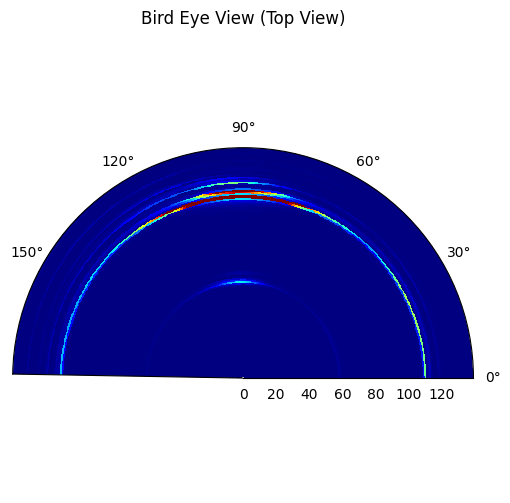

In [31]:
# Plot the output from 2D Beamforming (You can change this as you see fit)
fig = plt.figure(figsize=(20, 20))

to_plot = np.sum(abs(bf_output1),axis=1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
output_top = to_plot
ax1 = fig.add_subplot(142,projection = 'polar')
utils.plot_2d_heatmap(ax1, to_plot, phi, r_idxs, vmin=0, vmax=0.1)
ax1.title.set_text('Bird Eye View (Top View)')

plt.tight_layout()
plt.show()

In [263]:
import matplotlib.pyplot as plt

# Convert PyTorch tensor to NumPy
to_plot = torch.sum(torch.abs(bf_output1), dim=1)
to_plot = to_plot.cpu().numpy()  # convert to NumPy

# Normalize
to_plot = to_plot / np.max(to_plot.reshape(1, -1))
to_plot = to_plot ** 2
output_top = to_plot

# Plot
fig = plt.figure(figsize=(20, 20))
ax1 = fig.add_subplot(142, projection='polar')
utils.plot_2d_heatmap(ax1, to_plot, phi.cpu().numpy(), r_idxs, vmin=0, vmax=0.1)
ax1.title.set_text('Bird Eye View (Top View)')

plt.tight_layout()
plt.show()


TypeError: abs(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

In [40]:
# Import
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [41]:
# --- Inputs ---
# heatmap: 2D array, shape (azimuth, z)
# phi_array: 1D array of azimuth angles in degrees (length = heatmap.shape[0])
# z_res: resolution along z-axis in meters
# radar_range: estimated mean range to convert angles into lateral meters

n_phi, n_z = output_top.shape
phi_rad = np.deg2rad(phi)
z_coords_m = np.arange(n_z) * 1

# Convert azimuth (phi) to lateral X position at a fixed range
# Choose a representative range (e.g., middle of the radar’s field)
R_ref = 140  # e.g., 2.0 meters

x_coords_m = R_ref * np.tan(phi_rad)  # lateral offset in meters

# Build full coordinate grid
X, Z = np.meshgrid(x_coords_m, z_coords_m, indexing='ij')  # shape: (n_phi, n_z)

# Flatten for DBSCAN
points = np.stack([X.ravel(), Z.ravel()], axis=1)
powers = output_top.ravel()

# Optional: keep only high-power points
threshold = np.percentile(powers, 98)
valid_mask = powers > threshold
points_thresh = points[valid_mask]

# --- DBSCAN ---
db = DBSCAN(eps=2, min_samples=110).fit(points_thresh)
labels = db.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Detected {n_clusters} clusters (people).")

Detected 1 clusters (people).


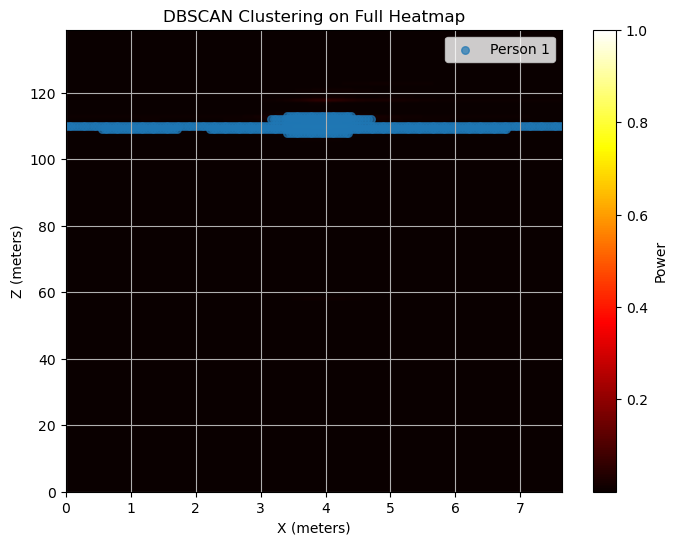

In [42]:
# Plot DBSCAN results
plt.figure(figsize=(8, 6))
plt.imshow(output_top.T, extent=[x_coords_m.min(), x_coords_m.max(), z_coords_m.min(), z_coords_m.max()],
           origin='lower', aspect='auto', cmap='hot')
plt.colorbar(label='Power')
plt.xlabel("X (meters)")
plt.ylabel("Z (meters)")
plt.title("DBSCAN Clustering on Full Heatmap")

# Plot clusters
for label in np.unique(labels):
    if label == -1:
        continue  # noise
    cluster_pts = points_thresh[labels == label]
    plt.scatter(cluster_pts[:,0], cluster_pts[:,1], s=30, label=f'Person {label+1}', alpha=0.7)

plt.legend()
plt.grid(True)
plt.show()

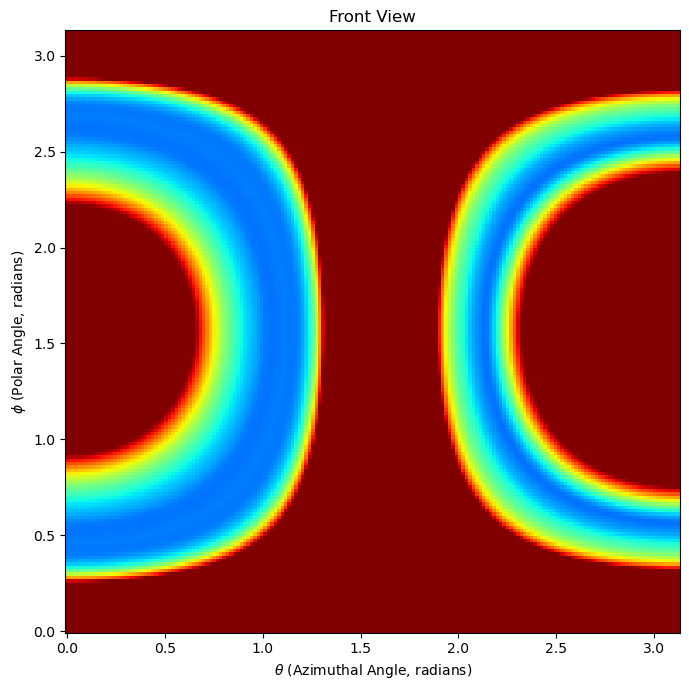

In [43]:
# Plot Front view
fig = plt.figure(figsize=(7, 7))

to_plot = np.sum(abs(bf_output1[:,:,20:40]),axis=-1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax0 = fig.add_subplot()
utils.plot_2d_polar_heatmap(ax0, to_plot, phi, theta, vmin=0, vmax=0.1)
ax0.title.set_text('Front View')

plt.tight_layout()
plt.show()

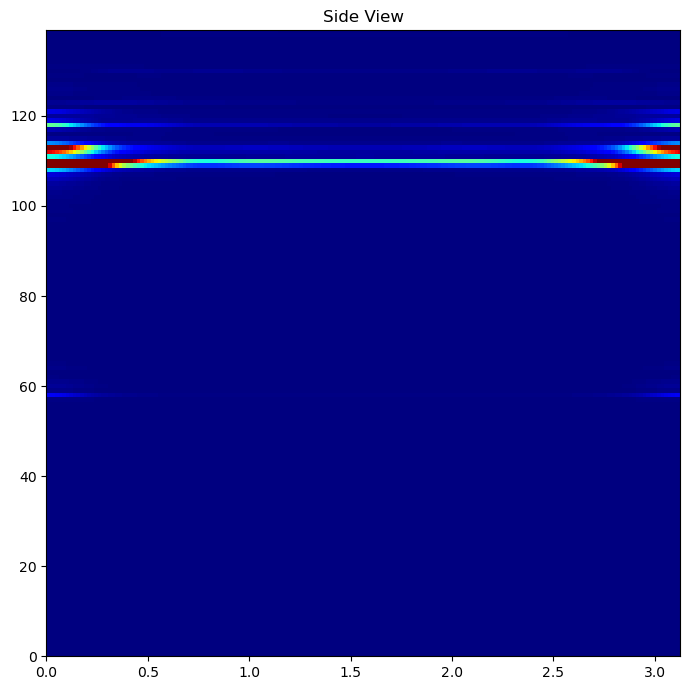

In [44]:
# Plot Side view
fig = plt.figure(figsize=(7, 7))

to_plot = np.sum(abs(bf_output1),axis=0)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax2 = fig.add_subplot()
utils.plot_2d_heatmap(ax2, to_plot, theta, r_idxs, vmin=0, vmax=0.1)
ax2.title.set_text('Side View')

plt.tight_layout()
plt.show()

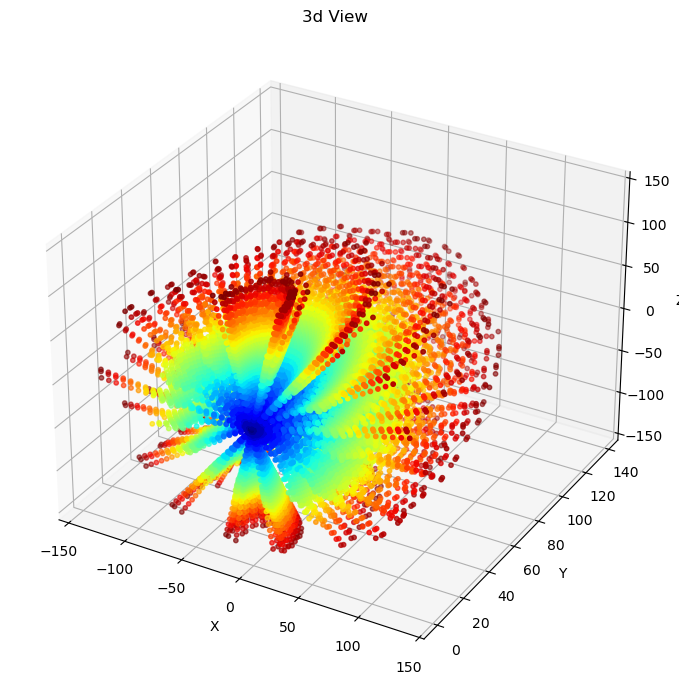

In [45]:
# Plot 3d view
fig = plt.figure(figsize=(7, 7))

to_plot = bf_output1
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax3 = fig.add_subplot(projection = '3d')
utils.plot_3d_polar_heatmap(ax3, to_plot, phi, theta, r_idxs, 0.1)
ax3.title.set_text('3d View')

plt.tight_layout()
plt.show()

In [4]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from tqdm import tqdm

# === File Paths ===
data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/input/data_mat/project/rdc_usejd_marche.mat'
static_data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/input/data_mat/project/rdc_vide.mat'

# === Load dynamic signal ===
radar_params, raw_data = utils.load_raw_data(data_path)  # (12, num_frames, 512)

# === Load static noise frame ===
_, raw_data_static = utils.load_raw_data(static_data_path)  # (12, 1, 512) or (12, 512)
if raw_data_static.ndim == 2:
    raw_data_static = raw_data_static[:, np.newaxis, :]  # (12, 1, 512)

# Pad static data if needed
if raw_data_static.shape[1] < radar_params['num_frames']:
    num_missing = radar_params['num_frames'] - raw_data_static.shape[1]
    last_frame = raw_data_static[:, -1:, :]  # shape: (12, 1, 512)
    padding = np.repeat(last_frame, num_missing, axis=1)  # (12, missing_frames, 512)
    raw_data_static = np.concatenate([raw_data_static, padding], axis=1)  # (12, 500, 512)


# === FFT both ===
beat_freq = np.fft.fft(raw_data, axis=-1)  # (12, num_frames, 512)
static_beat_freq = np.fft.fft(raw_data_static, axis=-1)  # (12, 1, 512)
beat_freq_super = beat_freq - static_beat_freq  # broadcasting over frames

# === Antenna positions ===
x_ant_pos, z_ant_pos, x_ant = utils.get_ant_pos_2d(
    radar_params_static['num_x_stp'],
    radar_params_static['num_z_stp'],
    radar_params_static['num_rx']
)

# === Beamforming parameters ===
r_idxs = np.arange(0, 140)
phi_s, phi_e, phi_res = 0, 180, 1
theta_s, theta_e, theta_res = 70, 110, 1
phi = np.radians(np.arange(phi_s, phi_e, phi_res))
theta = np.radians(np.arange(theta_s, theta_e, theta_res))
num_frames = radar_params['num_frames']

# === Precompute Beamforming ===
print("⚙️ Precomputing beamformed frames with noise removal...")
bf_frames = []
for i in tqdm(range(num_frames)):
    frame = beat_freq_super[:, i, :][:, np.newaxis, :]  # (12, 1, 512)

    bf, _, _ = beamform_2d(
        frame[:, :, r_idxs],
        phi_s, phi_e, phi_res,
        theta_s, theta_e, theta_res,
        x_ant_pos, z_ant_pos,
        r_idxs, radar_params
    )

    bf = np.abs(bf)
    bf /= np.max(bf)
    bf = bf ** 2
    bf_frames.append(np.sum(bf, axis=1))  # (phi, range)

# === Create animation ===
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='polar')

def update(frame_idx):
    ax.clear()
    to_plot = bf_frames[frame_idx]
    utils.plot_2d_heatmap(ax, to_plot, phi, r_idxs, vmin=0, vmax=0.1)
    ax.set_title(f'Top View Frame {frame_idx+1}/{num_frames}', va='bottom')
    return ax.collections

ani = animation.FuncAnimation(fig, update, frames=len(bf_frames), interval=50, blit=False)
ani.save("top_view_video.gif", writer='pillow', fps=20)
plt.close(fig)
print("✅ Saved: top_view_video.gif")

⚙️ Precomputing beamformed frames with noise removal...


100%|██████████| 500/500 [11:55<00:00,  1.43s/it]


✅ Saved: top_view_video.gif
